In [1]:
import csv
import numpy as np
from typing import Set,Tuple, List
import torch
import torch.utils
import torch.utils.data
import torch.nn as nn
import torchvision
NoneType = type(None)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.models import vgg11
from torchvision.models import mobilenet_v2
import torchvision.transforms as transforms
import time


In [2]:
# Quick dependency check and auto-install for this notebook
import importlib
import subprocess
import sys

# Map module name -> pip package name (generic libs)
modules = {
    "numpy": "numpy",          # np
    "torch": "torch",          # torch, nn (CPU or CUDA depending on how you installed it)
    "torchvision": "torchvision",  # datasets, models, transforms
    "matplotlib": "matplotlib",    # plt
    "PIL": "Pillow",           # Image
    "IPython": "ipython",      # display, clear_output
}

for module_name, package_name in modules.items():
    try:
        importlib.import_module(module_name)
        print(f"{module_name}: OK")
    except ImportError:
        print(f"{module_name}: MISSING, installing '{package_name}'...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
            importlib.import_module(module_name)
            print(f"  -> {module_name}: OK after installing '{package_name}'")
        except Exception as e:
            print(f"  -> FAILED to install '{package_name}': {e}")

# Check CUDA / DirectML availability and give guidance
try:
    import torch, torchvision
    print(f"torch version: {torch.__version__}") if hasattr(torch, "__version__") else print("torch version: no __version__")
    print(f"torchvision version: {torchvision.__version__}") if hasattr(torchvision, "__version__") else print("torchvision version: no __version__")
    
    has_cuda = torch.cuda.is_available()
    print(f"torch.cuda.is_available(): {has_cuda}")
    if has_cuda:
        print("CUDA is available. The notebook will default to running on CUDA.")
    else:
        print("CUDA is not available. Training will fall back to CPU unless DirectML is available.")
        # On Windows, try to install/use torch-directml for GPU acceleration on DirectX 12 GPUs (including Intel/AMD)
        dml_device = None
        if sys.platform.startswith("win"):
            try:
                import torch_directml #type: ignore
                print("torch_directml: OK")
            except ImportError:
                print("torch_directml: MISSING, trying to install 'torch-directml' (DirectML backend for many GPUs)...")
                try:
                    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-directml"])
                    import torch_directml #type: ignore
                    print("  -> torch_directml: OK after installing 'torch-directml'")
                except Exception as e:
                    torch_directml = None
                    print(f"  -> FAILED to install 'torch-directml': {e}")

            if 'torch_directml' in globals() and torch_directml is not None:
                try:
                    dml_device = torch_directml.device()
                    _ = torch.empty(1, device=dml_device)  # smoke test
                    print("DirectML backend is available. You can use this device via torch_directml.device().")
                    print("Example: device = torch_directml.device(); tensor.to(device)")
                except Exception as e:
                    dml_device = None
                    print(f"DirectML device not usable, staying on CPU: {e}")
        else:
            print("Non-Windows platform detected; torch-directml is not supported here.")
        if dml_device is None:
            print("NOTE: Using CPU for training. This is correct but slower.")
except Exception as e:
    print(f"Could not check CUDA/DirectML availability: {e}")


numpy: OK
torch: OK
torchvision: OK
matplotlib: OK
PIL: OK
IPython: OK
torch version: 2.4.1+cpu
torchvision version: 0.19.1+cpu
torch.cuda.is_available(): False
CUDA is not available. Training will fall back to CPU unless DirectML is available.
torch_directml: OK
DirectML backend is available. You can use this device via torch_directml.device().
Example: device = torch_directml.device(); tensor.to(device)


<h1 id="exercise-1"><strong>Exercise 1</strong></h1>


<font size="4px"><p>This method returns the fruit name by getting the string at a specific index of the set.</p>
<dl>
<dt>param fruit_id</dt>
<dd><p>The id of the fruit to get</p>
</dd>
<dt>param fruits</dt>
<dd><p>The set of fruits to choose the id from</p>
</dd>
<dt>return</dt>
<dd><p>The string corrosponding to the index <code>fruit_id</code></p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   It does not print the fruit at the correct index, why is the returned result wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue: name1, name3 and name4 are expected to correspond to the strings at the indices 1, 3, and 4: 'orange', 'kiwi' and 'strawberry'..</p>
</font>

In [3]:
# You can copy this code to your personal pipeline project or execute it here.
from collections.abc import Sequence


def id_to_fruit(fruit_id: int, fruits: Sequence[str]) -> str:
    """
    This method returns the fruit name by getting the string at a specific index of the set.

    :param fruit_id: The id of the fruit to get
    :param fruits: The set of fruits to choose the id from
    :return: The string corrosponding to the index ``fruit_id``

    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    | ``1   It does not print the fruit at the correct index, why is the returned result wrong?``
    | ``2   How could this be fixed?``

    This example demonstrates the issue:
    name1, name3 and name4 are expected to correspond to the strings at the indices 1, 3, and 4:
    'orange', 'kiwi' and 'strawberry'..

    >>> name1 = id_to_fruit(1, {"apple", "orange", "melon", "kiwi", "strawberry"})
    >>> name3 = id_to_fruit(3, {"apple", "orange", "melon", "kiwi", "strawberry"})
    >>> name4 = id_to_fruit(4, {"apple", "orange", "melon", "kiwi", "strawberry"})
    """
    idx = 0
    for fruit in fruits:
        if fruit_id == idx:
            return fruit
        idx += 1
    raise RuntimeError(f"Fruit with id {fruit_id} does not exist")



In [4]:
# chaged the set to a list because sets are unordered and do not support indexing.
# defined Fruits as a Sequence of strings instead.

name1 = id_to_fruit(1, ["apple", "orange", "melon", "kiwi", "strawberry"])
name3 = id_to_fruit(3, ["apple", "orange", "melon", "kiwi", "strawberry"])
name4 = id_to_fruit(4, ["apple", "orange", "melon", "kiwi", "strawberry"])

print(f"name1, 3 and 4: {name1}, {name3} and {name4}")
print("in expected order: 'orange', 'kiwi' and 'strawberry'..")


name1, 3 and 4: orange, kiwi and strawberry
in expected order: 'orange', 'kiwi' and 'strawberry'..


<h1 id="exercise-2"><strong>Exercise 2</strong></h1>


<font size="4px"><p>This method will flip the x and y coordinates in the coords array.</p>
<dl>
<dt>param coords</dt>
<dd><p>A numpy array of bounding box coordinates with shape [n,5] in format: :</p>
<pre><code>[[x11, y11, x12, y12, classid1],
 [x21, y21, x22, y22, classid2],
 ...
 [xn1, yn1, xn2, yn2, classid3]]</code></pre>
</dd>
<dt>return</dt>
<dd><p>The new numpy array where the x and y coordinates are flipped.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   Can you spot the obvious error?</code><br />
<code>2   After fixing the obvious error it is still wrong, how can this be fixed?</code></div>
</font>

<font size="4px"><p>The example demonstrates the issue. The returned swapped_coords are expected to have swapped x and y coordinates in each of the rows.</p>
</font>

In [5]:
# You can copy this code to your personal pipeline project or execute it here.
def swap(coords: np.ndarray)-> np.ndarray:
    """
    This method will flip the x and y coordinates in the coords array.

    :param coords: A numpy array of bounding box coordinates with shape [n,5] in format:
        ::

            [[x11, y11, x12, y12, classid1],
             [x21, y21, x22, y22, classid2],
             ...
             [xn1, yn1, xn2, yn2, classid3]]

    :return: The new numpy array where the x and y coordinates are flipped.

    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    | ``1   Can you spot the obvious error?``
    | ``2   After fixing the obvious error it is still wrong, how can this be fixed?``

    >>> import numpy as np
    >>> coords = np.array([[10, 5, 15, 6, 0],
    ...                    [11, 3, 13, 6, 0],
    ...                    [5, 3, 13, 6, 1],
    ...                    [4, 4, 13, 6, 1],
    ...                    [6, 5, 13, 16, 1]])
    >>> swapped_coords = swap(coords)

    The example demonstrates the issue. The returned swapped_coords are expected to have swapped
    x and y coordinates in each of the rows.
    """
    # coords[:, 0], coords[:, 1], coords[:, 2], coords[:, 3], = coords[:, 1], coords[:, 1], coords[:, 3], coords[:, 2]
    # ^ this is way to many words for me to even understand what is going on. if you wanna flip these numbers, the following is mutch clearer:
    coords[:, [0, 1, 2, 3]] = coords[:, [1, 0, 3, 2]]
    # it is nice to learn this array and ndarray interaction.
    # apparently; ":" means "all rows", which seems to activate some sort of baked in forloop which is how these types work together
    # sad that np.ndarray hase no docstring or type hints that explain or show this interaction.
    return coords



In [6]:
import numpy as np
coords = np.array([[10, 5, 15, 6, 0],
                   [11, 3, 13, 6, 0],
                   [5, 3, 13, 6, 1],
                   [4, 4, 13, 6, 1],
                   [6, 5, 13, 16, 1]])
swapped_coords = swap(coords)
print(swapped_coords)


[[ 5 10  6 15  0]
 [ 3 11  6 13  0]
 [ 3  5  6 13  1]
 [ 4  4  6 13  1]
 [ 5  6 16 13  1]]


<h1 id="exercise-3"><strong>Exercise 3</strong></h1>


<font size="4px"><p>This code plots the precision-recall curve based on data from a .csv file, where precision is on the x-axis and recall is on the y-axis. It is (\<typo: the was "it it" in here originally>) not so important right now what precision and recall means.</p>
<dl>
<dt>param csv_file_path</dt>
<dd><p>The CSV file containing the data to plot.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   For some reason the plot is not showing correctly, can you find out what is going wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue. It first generates some data in a csv file format and the plots it using the <code>plot_data</code> method. If you manually check the coordinates and then check the plot, they do not correspond.</p>
</font>

In [7]:
# You can copy this code to your personal pipeline project or execute it here.
def plot_data(csv_file_path: str):
    """
    This code plots the precision-recall curve based on data from a .csv file,
    where precision is on the x-axis and recall is on the y-axis.
    It it not so important right now what precision and recall means.

    :param csv_file_path: The CSV file containing the data to plot.


    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    | ``1   For some reason the plot is not showing correctly, can you find out what is going wrong?``
    | ``2   How could this be fixed?``

    This example demonstrates the issue.
    It first generates some data in a csv file format and the plots it using the ``plot_data`` method.
    If you manually check the coordinates and then check the plot, they do not correspond.

    >>> f = open("data_file.csv", "w")
    >>> w = csv.writer(f)
    >>> _ = w.writerow(["precision", "recall"])
    >>> w.writerows([[0.013,0.951],
    ...              [0.376,0.851],
    ...              [0.441,0.839],
    ...              [0.570,0.758],
    ...              [0.635,0.674],
    ...              [0.721,0.604],
    ...              [0.837,0.531],
    ...              [0.860,0.453],
    ...              [0.962,0.348],
    ...              [0.982,0.273],
    ...              [1.0,0.0]])
    >>> f.close()
    >>> plot_data('data_file.csv')
    """
    # load data
    # results = []
    # with open(csv_file_path) as result_csv:
    #     csv_reader = csv.reader(result_csv, delimiter=',')
    #     next(csv_reader)              # skip header
    #     for row in csv_reader:
    #         results.append(row)       # each row is a list of strings
    #     results = np.stack(results)   # ValueError: stack needs equal lengths of rows. 1.0, 0.0 is not the same length as 0.013, 0.951

    # # plot precision-recall curve
    # plt.plot(results[:, 1], results[:, 0])
    # plt.ylim([-0.05, 1.05])
    # plt.xlim([-0.05, 1.05])
    data = np.loadtxt(csv_file_path, delimiter=",", skiprows=1) # I like using panda DataFrames for this kind if thing, but this is fine too.
    x = data[:, 0]
    y = data[:, 1]
    plt.plot(x, y, marker="o")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()



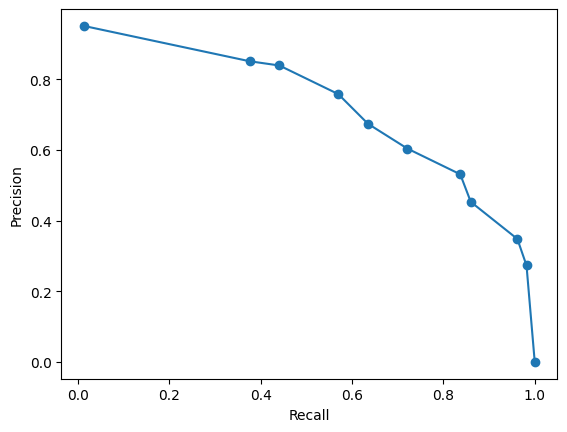

In [8]:
f = open("data_file.csv", "w")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data('data_file.csv')


<h1 id="generator-for-exercise-4">** Generator (for Exercise 4)**</h1>


<font size="4px"><p>Generator class for the GAN</p>
</font>

In [9]:
# You can copy this code to your personal pipeline project or execute it here.
class Generator(nn.Module):
    """
    Generator class for the GAN
    """

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output



<h1 id="discriminator-for-exercise-4">** Discriminator (for Exercise 4)**</h1>


<font size="4px"><p>Discriminator class for the GAN</p>
</font>

In [10]:
# You can copy this code to your personal pipeline project or execute it here.
class Discriminator(nn.Module):
    """
    Discriminator class for the GAN
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output



<h1 id="exercise-4">** Exercise 4**</h1>


<font size="4px"><p>The method trains a Generative Adversarial Network and is based on: <a href="https://realpython.com/generative-adversarial-networks/">https://realpython.com/generative-adversarial-networks/</a></p>
<p>The Generator network tries to generate convincing images of handwritten digits. The Discriminator needs to detect if the image was created by the Generater or if the image is a real image from a known dataset (MNIST). If both the Generator and the Discriminator are optimized, the Generator is able to create images that are difficult to distinguish from real images. This is goal of a GAN.</p>
<p>This code produces the expected results at first attempt at about 50 epochs.</p>
<dl>
<dt>param batch_size</dt>
<dd><p>The number of images to train in one epoch.</p>
</dd>
<dt>param num_epochs</dt>
<dd><p>The number of epochs to train the gan.</p>
</dd>
<dt>param device</dt>
<dd><p>The computing device to use. If CUDA is installed and working then <span class="title-ref">cuda:0</span> is chosen otherwise 'cpu' is chosen. Note: Training a GAN on the CPU is very slow.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<p>It contains at least two bugs: one structural bug and one cosmetic bug. Both bugs are from the original tutorial.</p>
<div class="line-block"><code>1   Changing the batch_size from 32 to 64 triggers the structural bug.</code><br />
<code>2   Can you also spot the cosmetic bug?</code><br />
<code>Note: to fix this bug a thorough understanding of GANs is not necessary.</code></div>
<p>Change the batch size to 64 to trigger the bug with message: ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."</p>
</font>

In [11]:
# You can copy this code to your personal pipeline project or execute it here.
def train_gan(batch_size: int = 32, num_epochs: int = 100, device=None):
    """
    The method trains a Generative Adversarial Network and is based on:
    https://realpython.com/generative-adversarial-networks/

.
    The Generator network tries to generate convincing images of handwritten digits.
    The Discriminator needs to detect if the image was created by the Generater or if the image
    is a real image from a known dataset (MNIST).
    If both the Generator and the Discriminator are optimized, the Generator is able to create
    images that are difficult to distinguish from real images. This is goal of a GAN.

.
    This code produces the expected results at first attempt at about 50 epochs.

.
    :param batch_size: The number of images to train in one epoch.
    :param num_epochs: The number of epochs to train the gan.
    :param device: The computing device to use.
        If None (default), the function will try, in order:
            1) CUDA GPU ("cuda:0"),
            2) DirectML GPU via torch_directml.device() (if available),
            3) CPU.

        Note: Training a GAN on the CPU is very slow.

    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    It contains at least two bugs: one structural bug and one cosmetic bug. Both bugs are from the original tutorial.

    | ``1   Changing the batch_size from 32 to 64 triggers the structural bug.``
    | ``2   Can you also spot the cosmetic bug?``
    | ``Note: to fix this bug a thorough understanding of GANs is not necessary.``

    Change the batch size to 64 to trigger the bug with message:
    ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."

    >>> train_gan(batch_size=32, num_epochs=100)
    """
    # Select device if not provided explicitly
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda:0")
            print(f"Using CUDA device: {device}")
        else:
            # Try DirectML via torch_directml
            try:
                import torch_directml #type: ignore
                dml_device = torch_directml.device()
                _ = torch.empty(1, device=dml_device)  # smoke test
                device = dml_device
                print("Using DirectML device via torch_directml.")
            except Exception as e:
                device = torch.device("cpu")
                print(f"DirectML not available/usable, falling back to CPU. Reason: {e}")
    else:
        print(f"Using user-specified device: {device}")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])

    # Load MNIST, with fallback URLs if the default download fails
    try:
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except Exception:
        print("Failed to download MNIST, retrying with different URL")
        # see: https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py
        torchvision.datasets.MNIST.resources = [
            (
                "https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz",
                "f68b3c2dcbeaaa9fbdd348bbdeb94873",
            ),
            (
                "https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz",
                "d53e105ee54ea40749a09fcbcd1e9432",
            ),
            (
                "https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz",
                "9fb629c4189551a2d022fa330f9573f3",
            ),
            (
                "https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz",
                "ec29112dd5afa0611ce80d1b7f02629c",
            ),
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

    # Example data: show some real images
    real_samples, mnist_labels = next(iter(train_loader))
    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis("off")
    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)
    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)
    generator = Generator().to(device)
    lr = 0.0001
    loss_function = nn.BCELoss()
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # Train
    for epoch in range(num_epochs):
        for n, (real_samples, mnist_labels) in enumerate(train_loader):
            current_batch_size = real_samples.size(0)

            # Data for training the discriminator
            real_samples = real_samples.to(device=device)
            real_samples_labels = torch.ones((current_batch_size, 1), device=device)
            latent_space_samples = torch.randn((current_batch_size, 100), device=device)
            generated_samples = generator(latent_space_samples)
            generated_samples_labels = torch.zeros((current_batch_size, 1), device=device)
            all_samples = torch.cat((real_samples, generated_samples))
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((current_batch_size, 100), device=device)

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(
                output_discriminator_generated,
                torch.ones((current_batch_size, 1), device=device),
            )
            loss_generator.backward()
            optimizer_generator.step()

            # Show loss and samples generated on last batch of each epoch
            if n == len(train_loader) - 1:
                name = (
                    f"Generate images\n Epoch: {epoch} "
                    f"Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                )
                generated_samples_np = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples_np[i].reshape(28, 28), cmap="gray_r")
                    sub.axis("off")
                fig.suptitle(name)
                fig.tight_layout()
                clear_output(wait=False)
                display(fig)

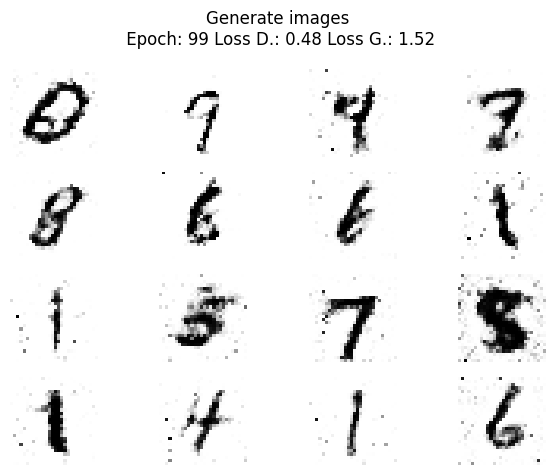

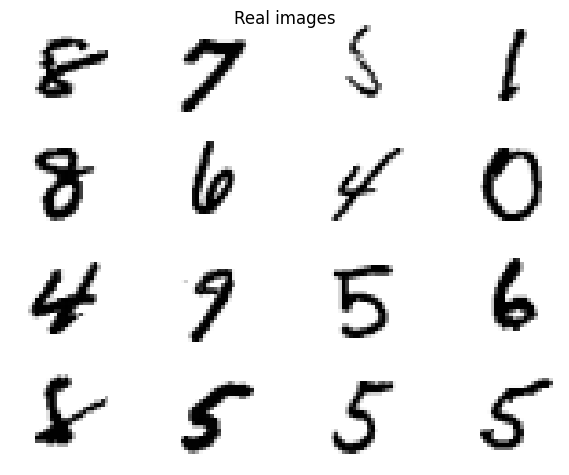

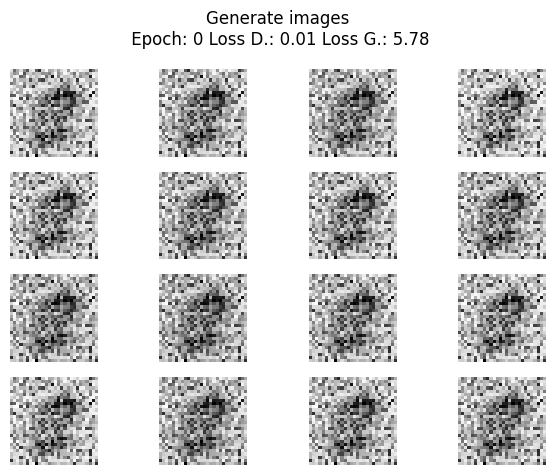

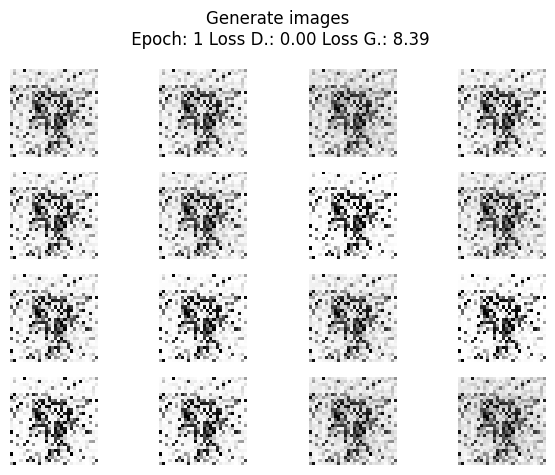

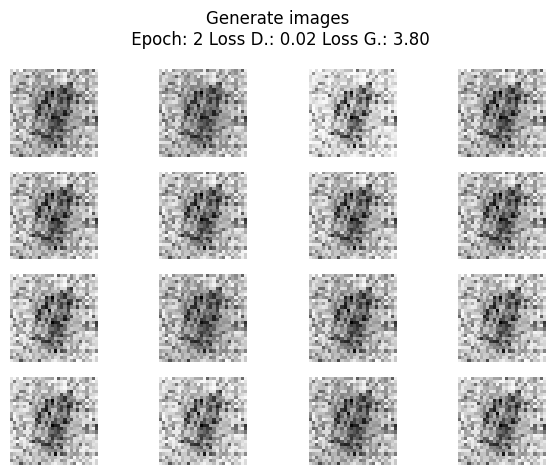

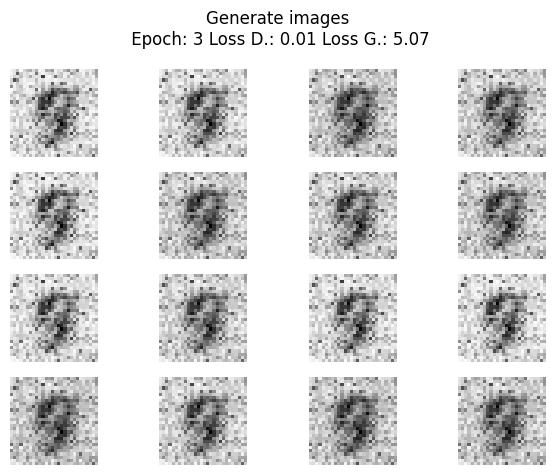

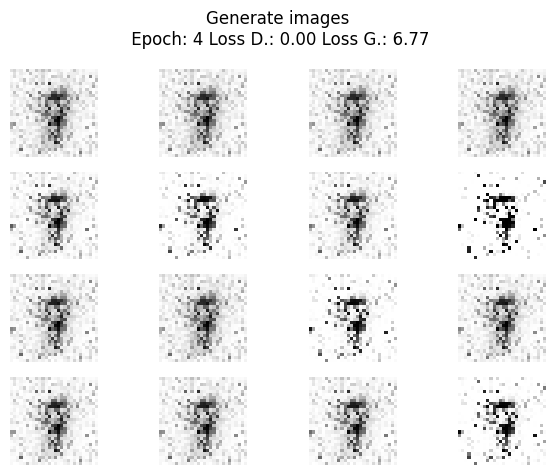

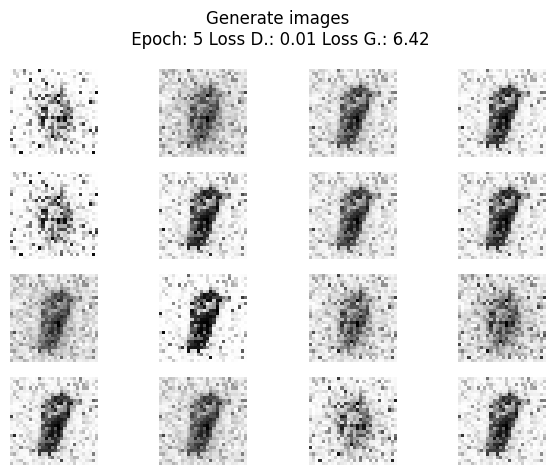

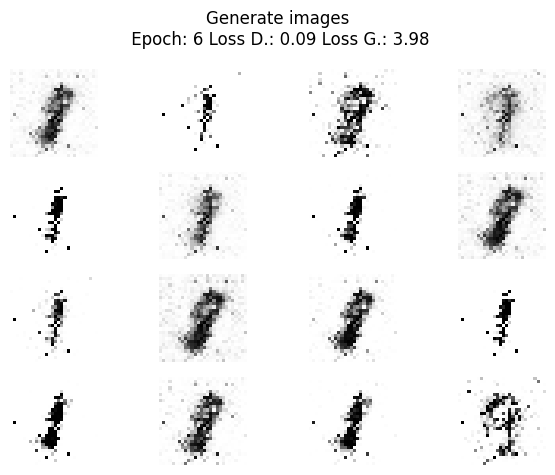

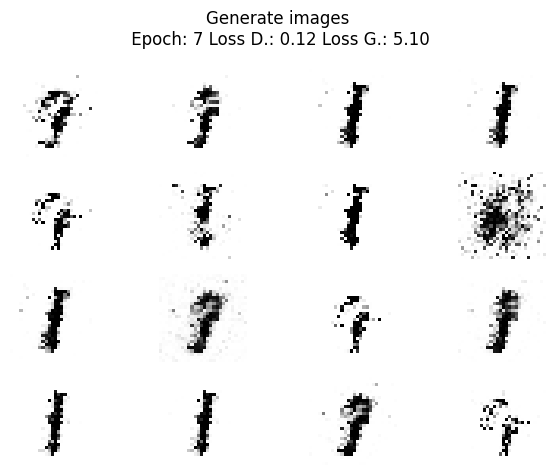

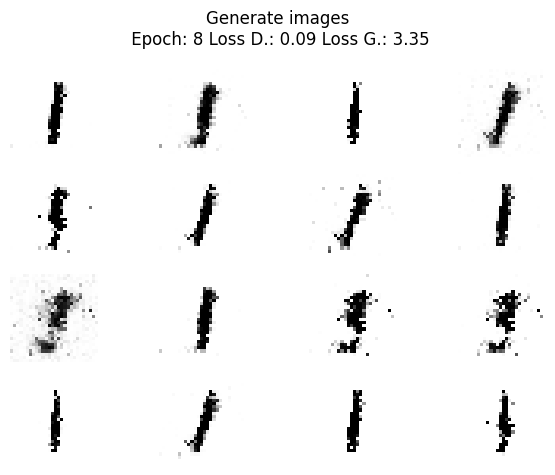

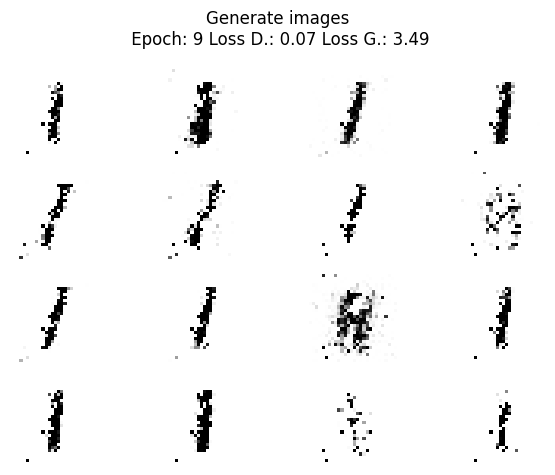

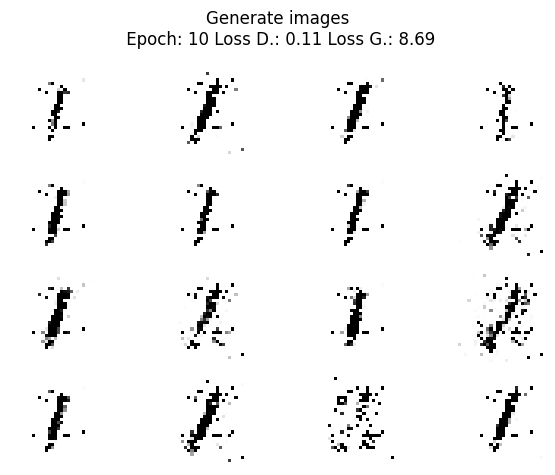

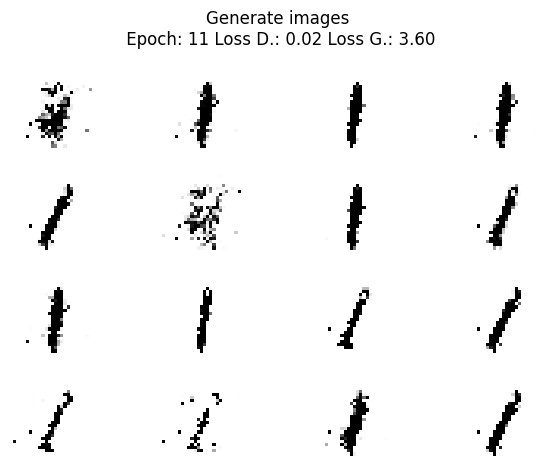

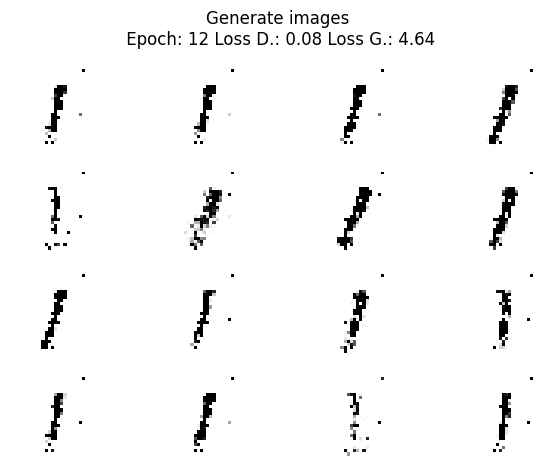

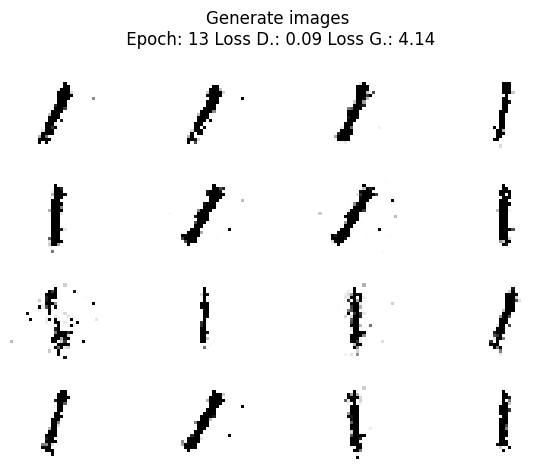

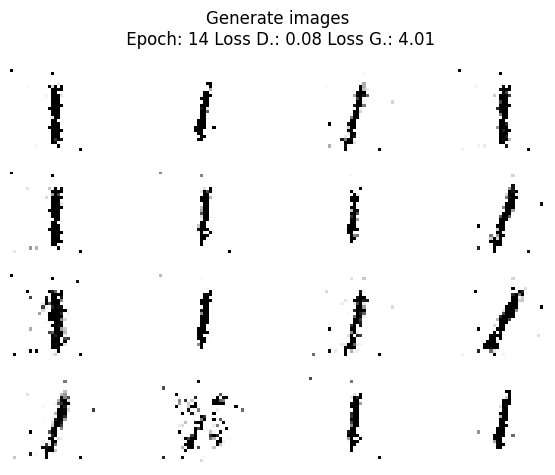

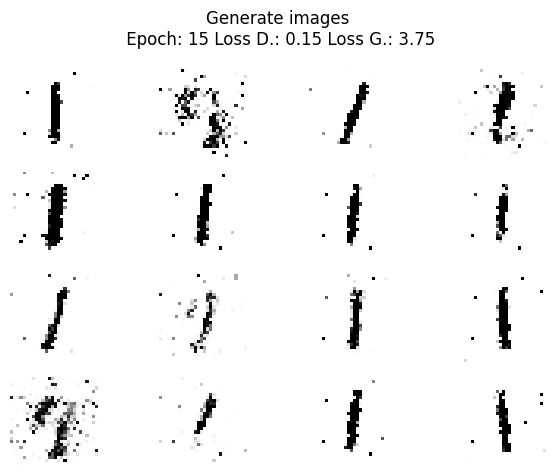

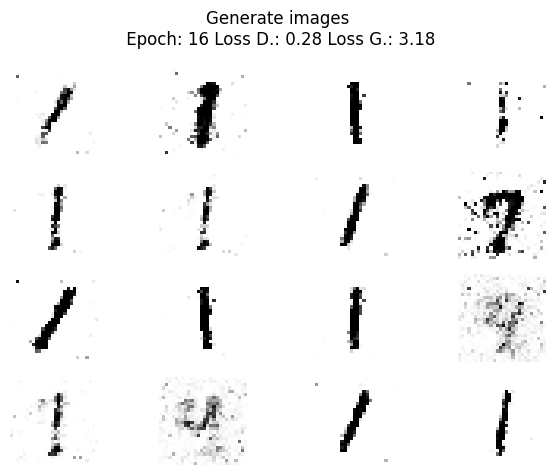

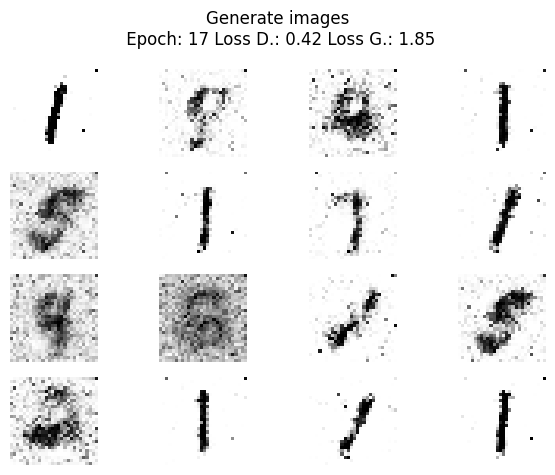

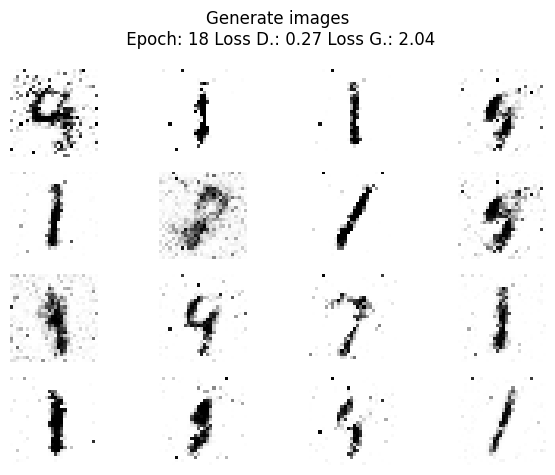

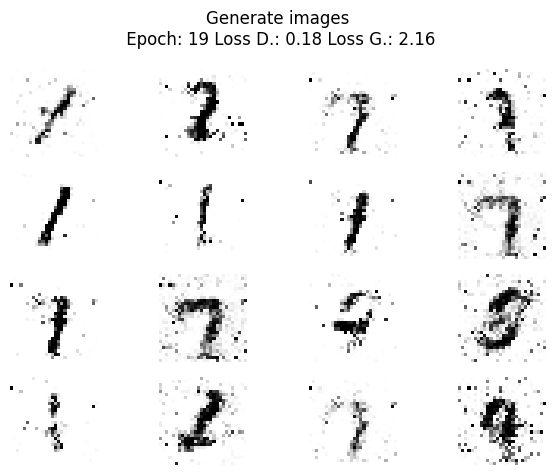

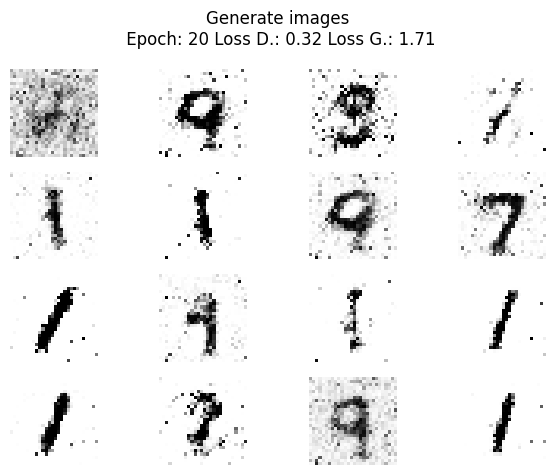

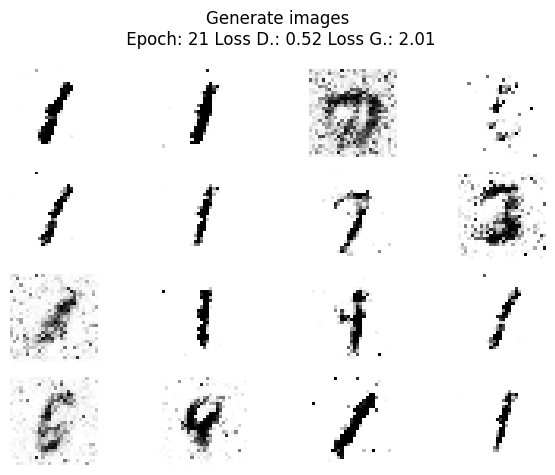

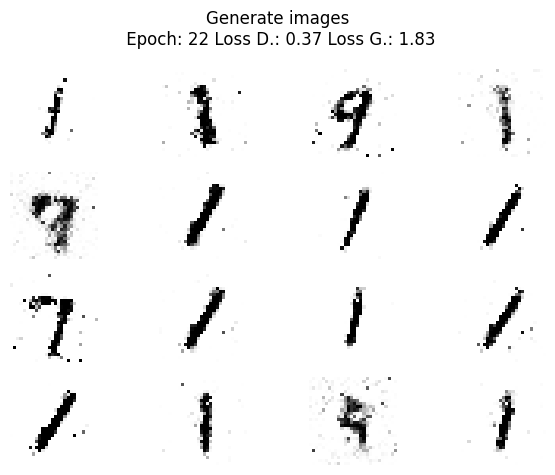

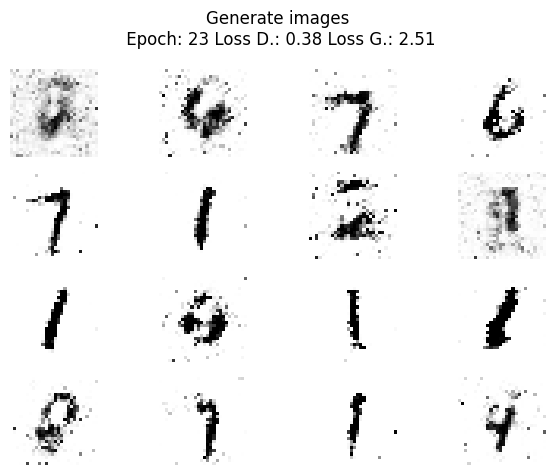

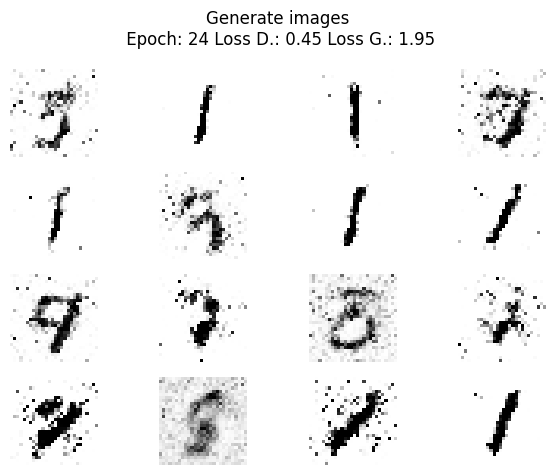

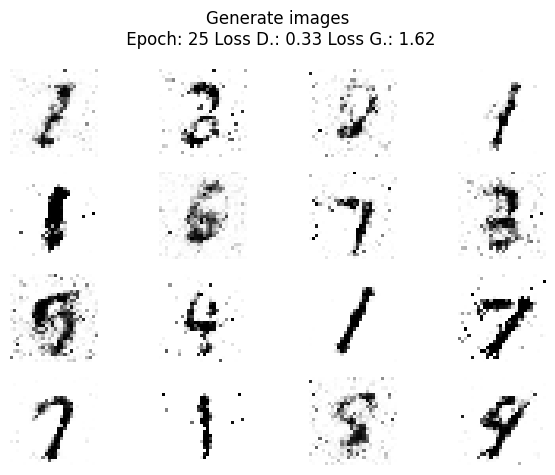

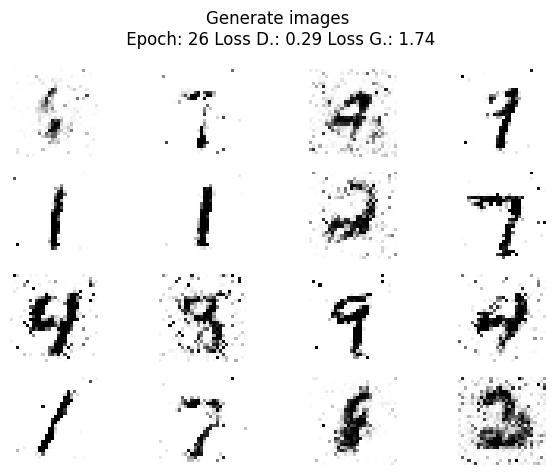

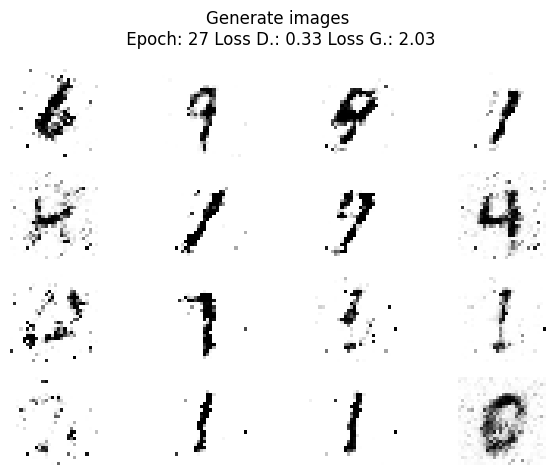

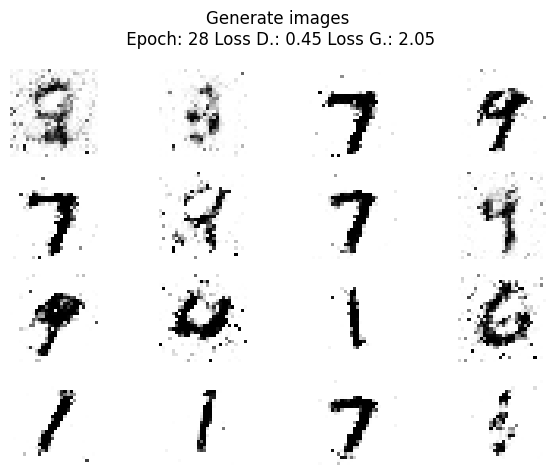

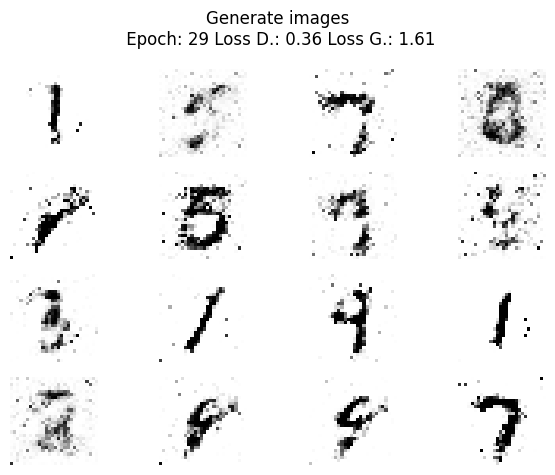

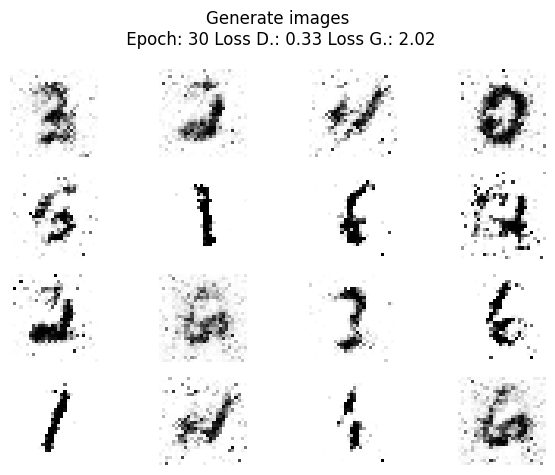

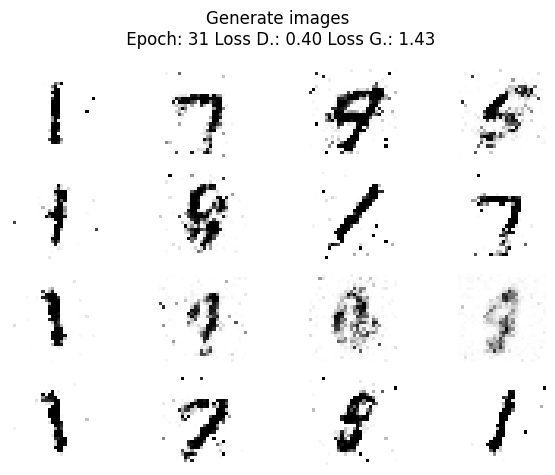

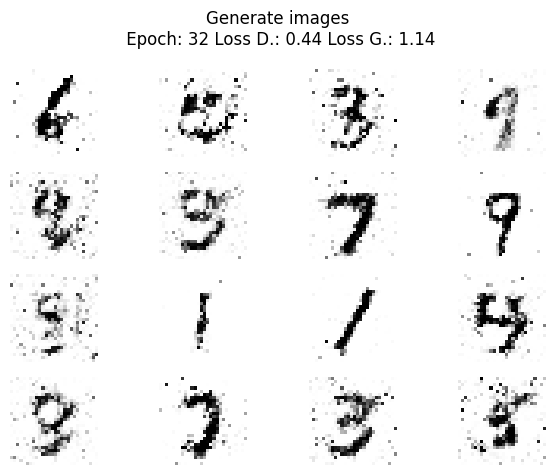

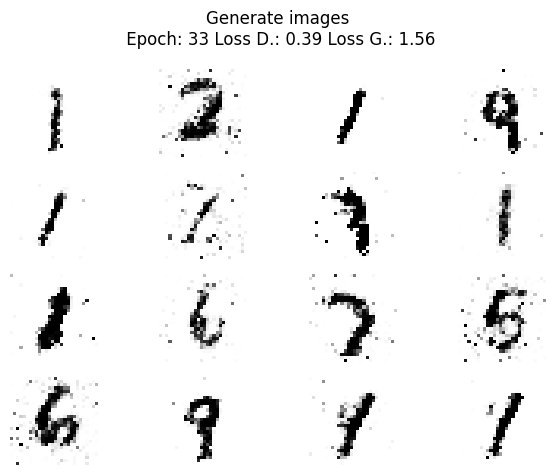

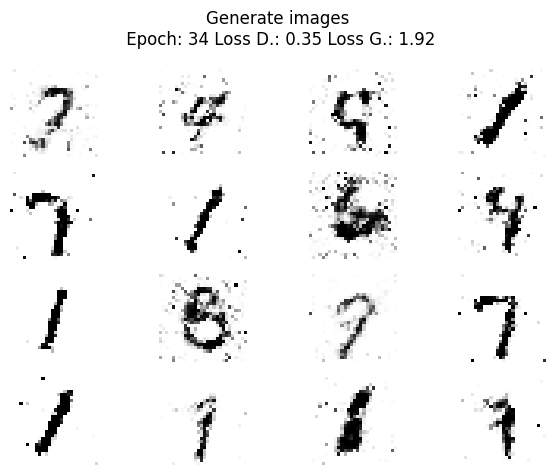

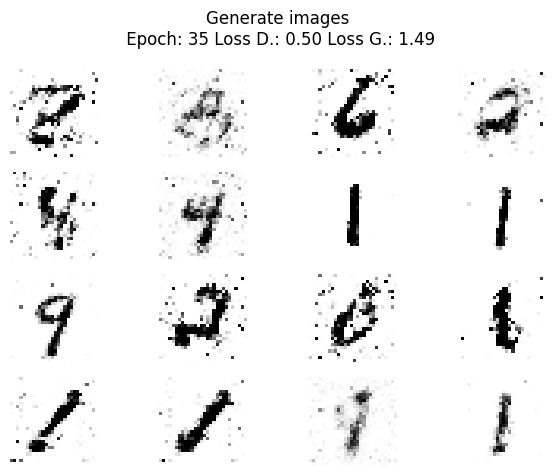

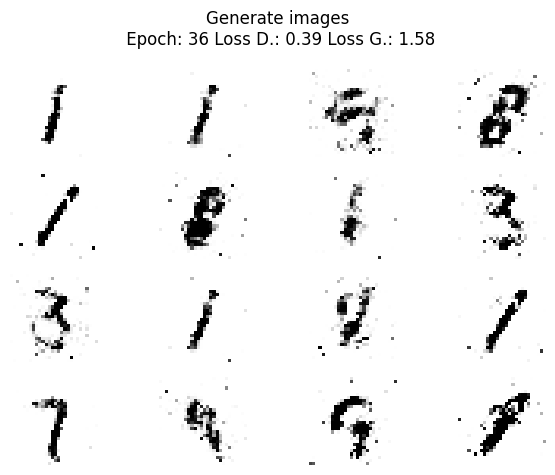

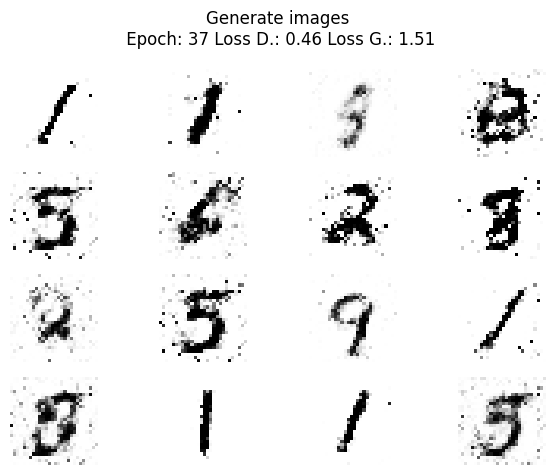

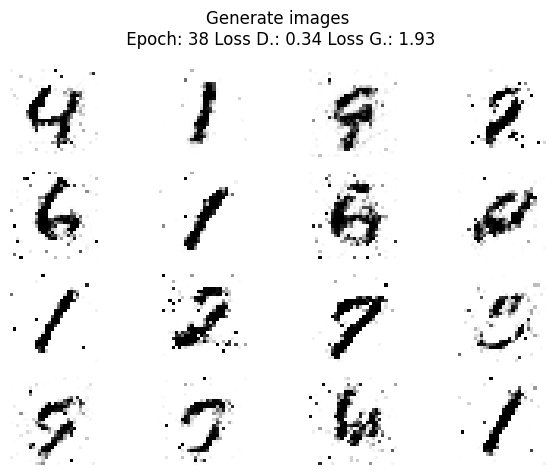

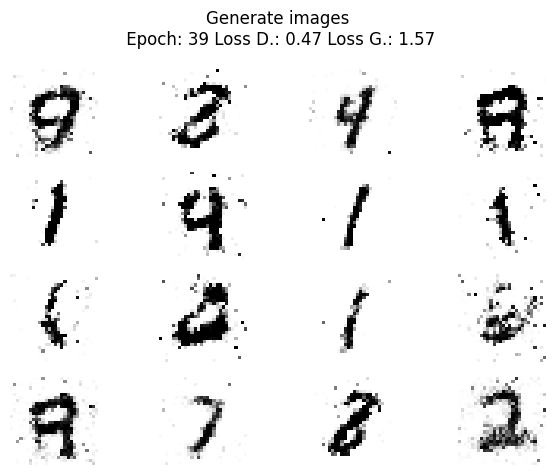

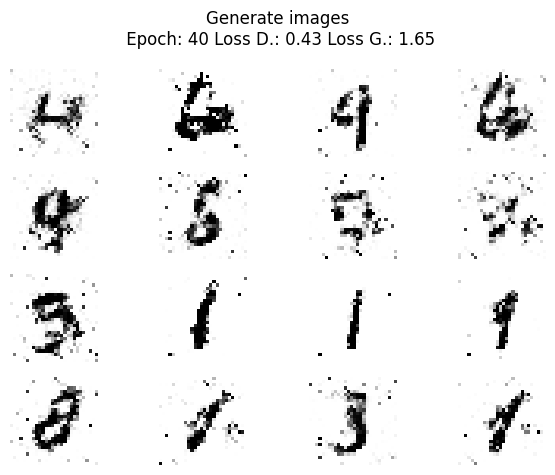

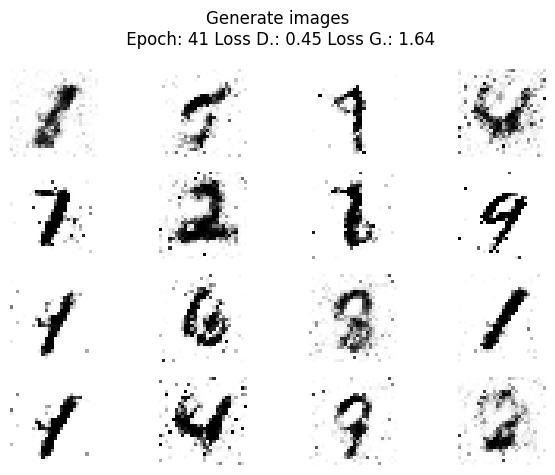

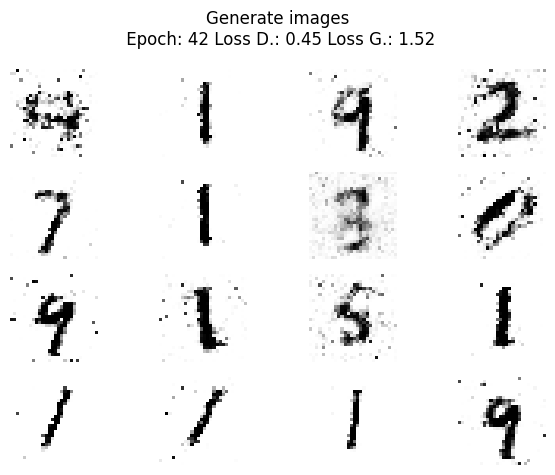

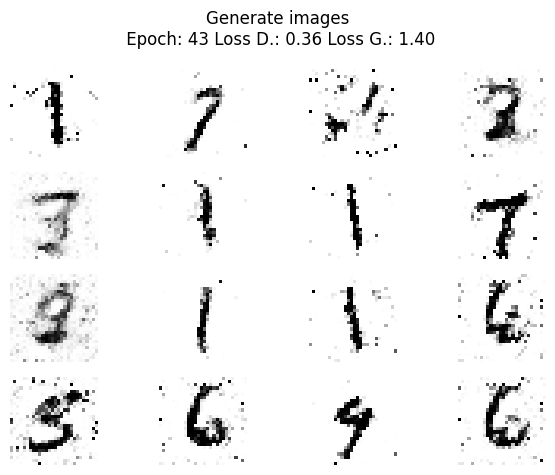

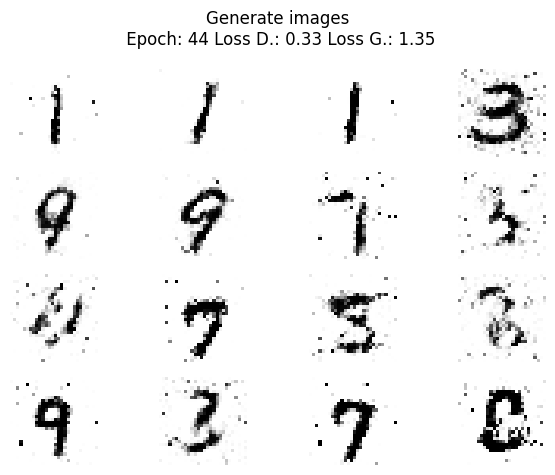

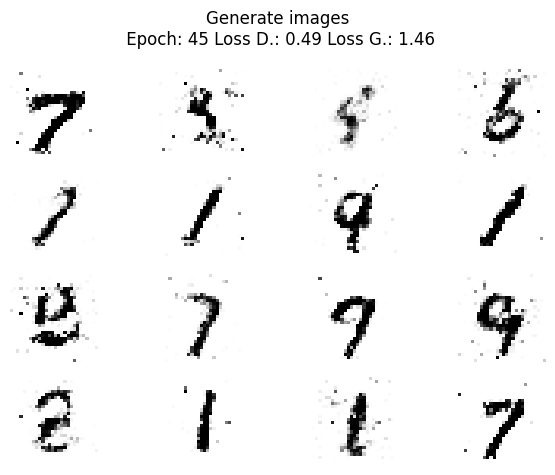

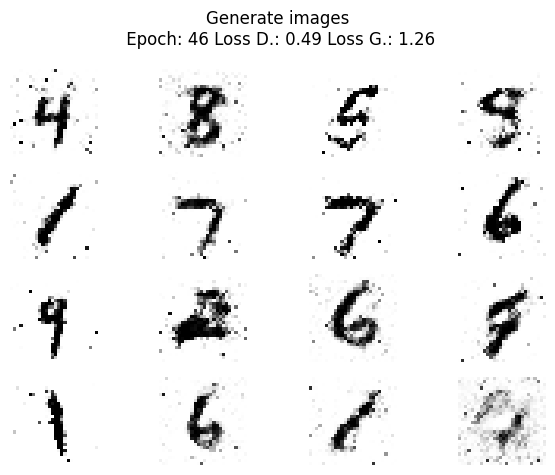

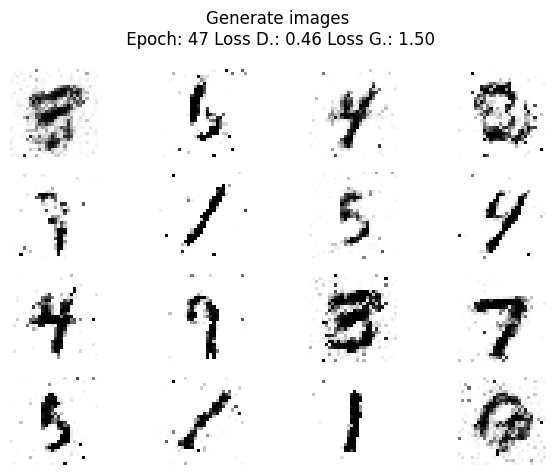

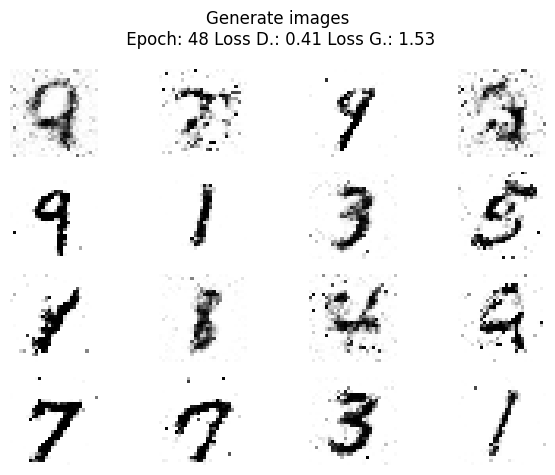

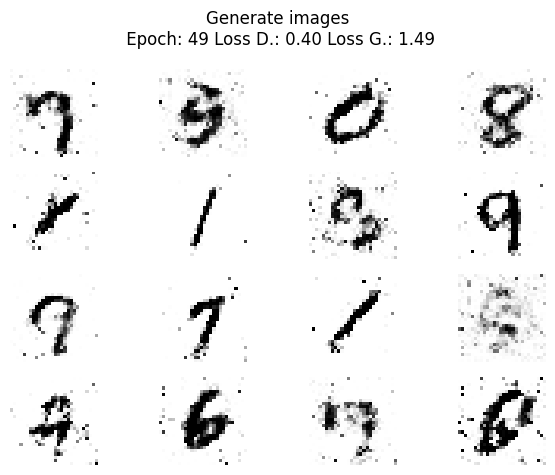

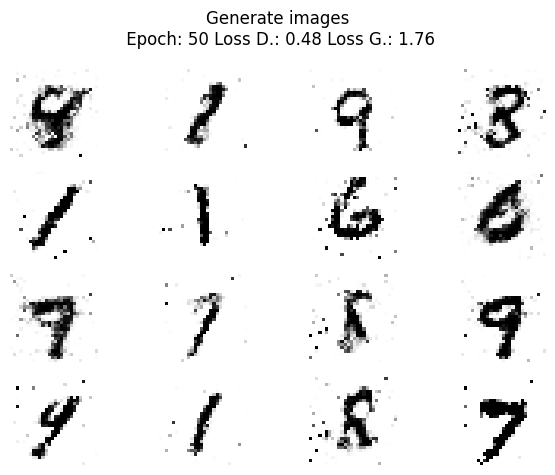

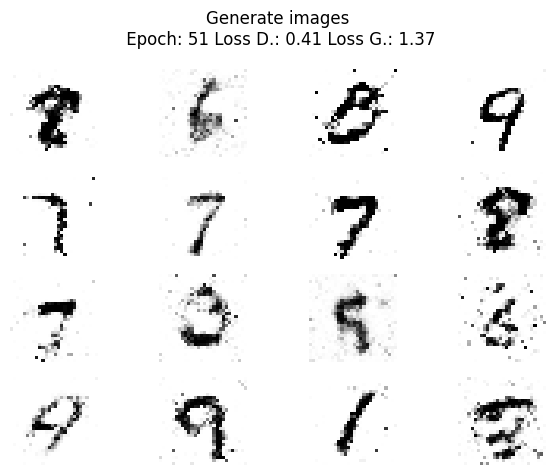

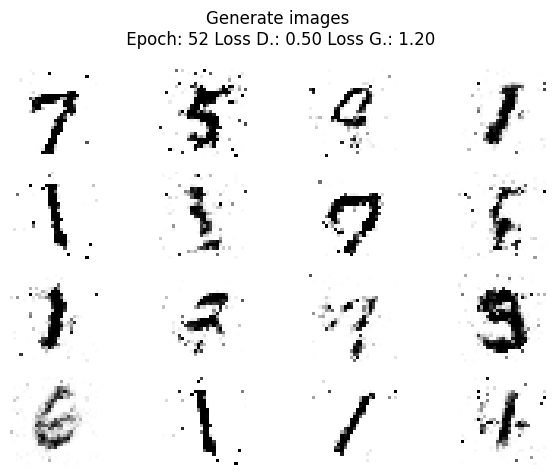

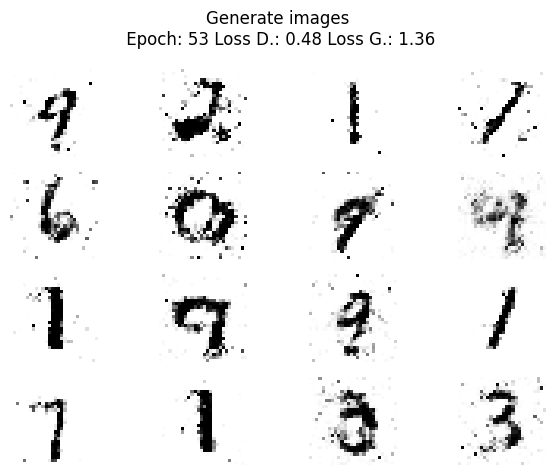

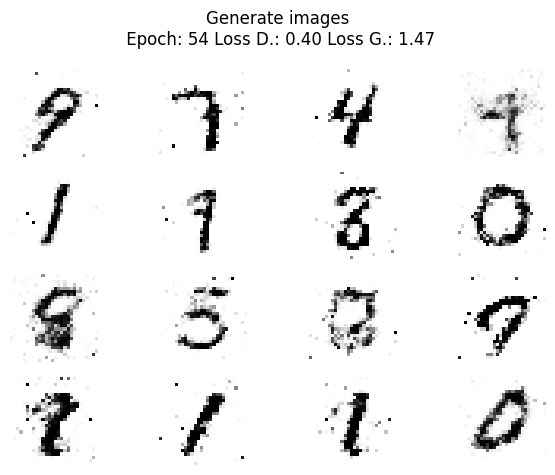

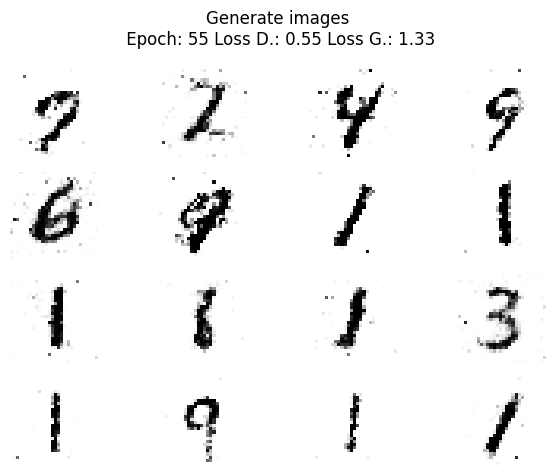

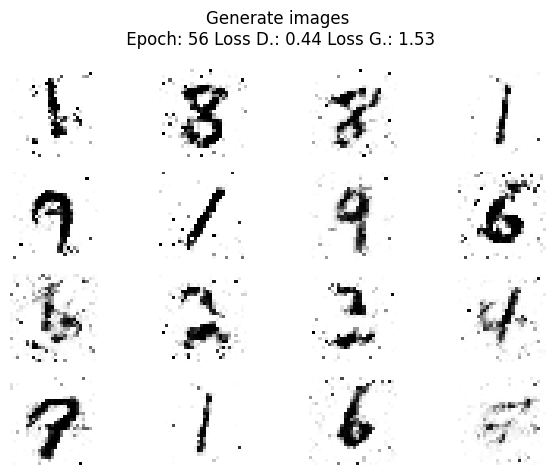

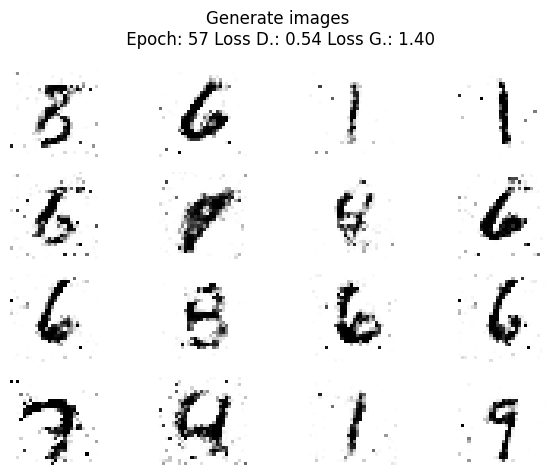

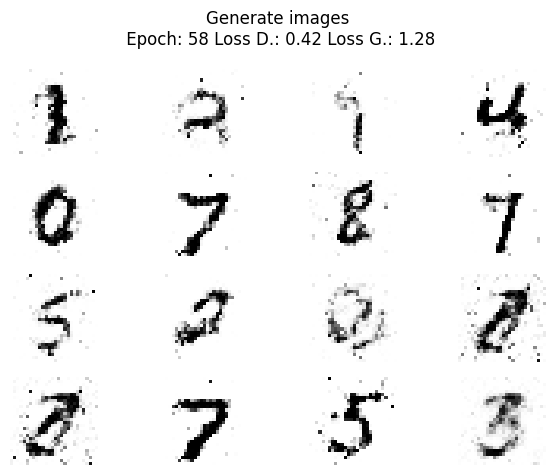

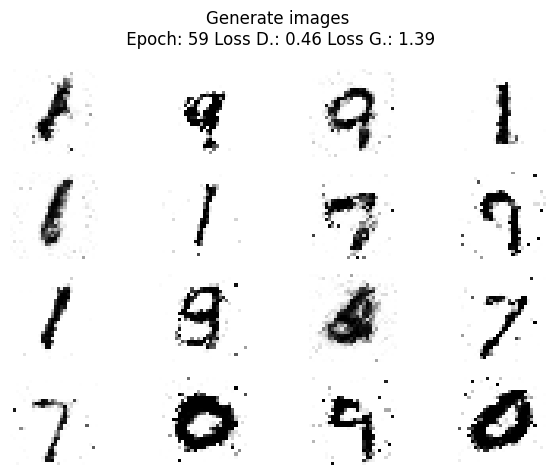

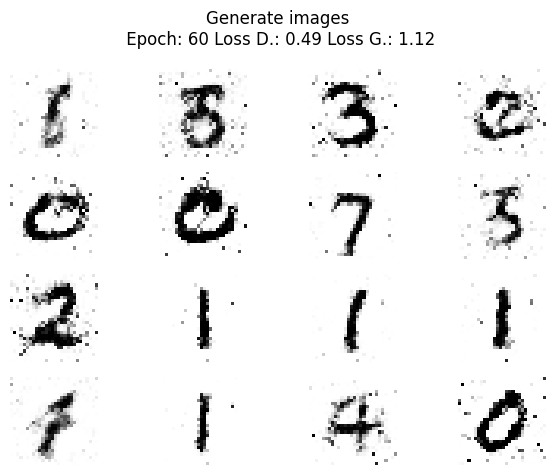

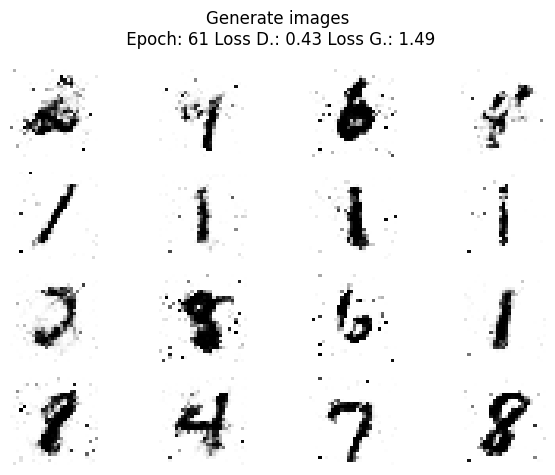

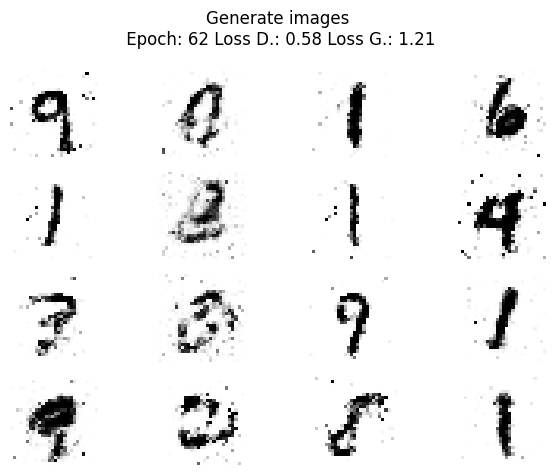

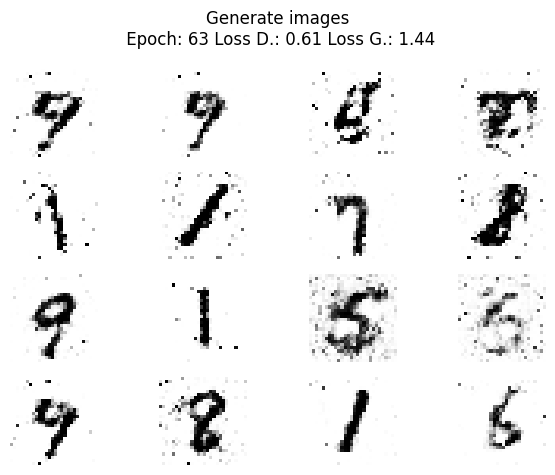

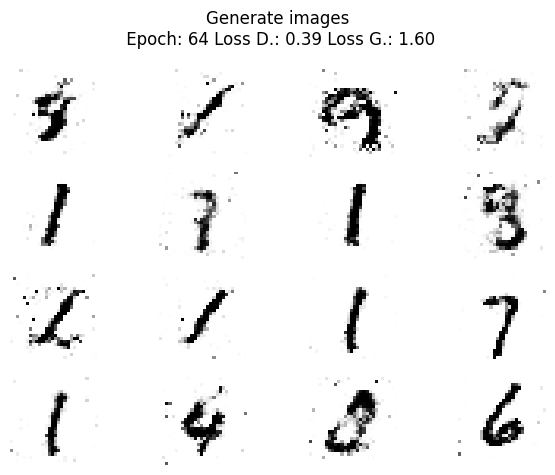

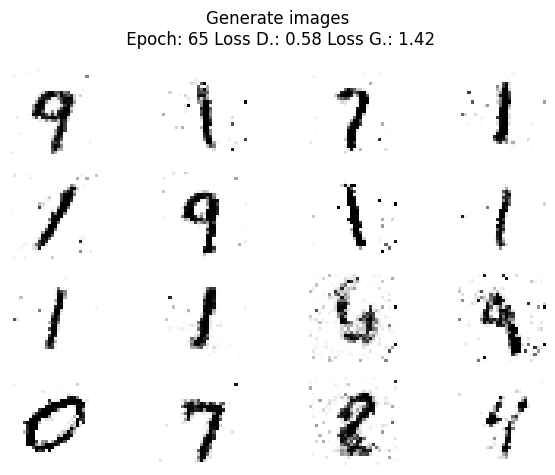

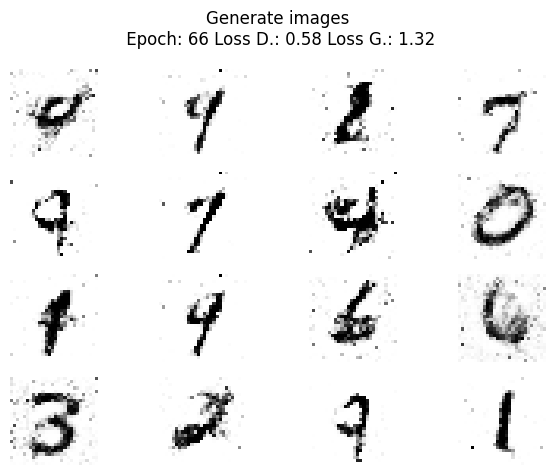

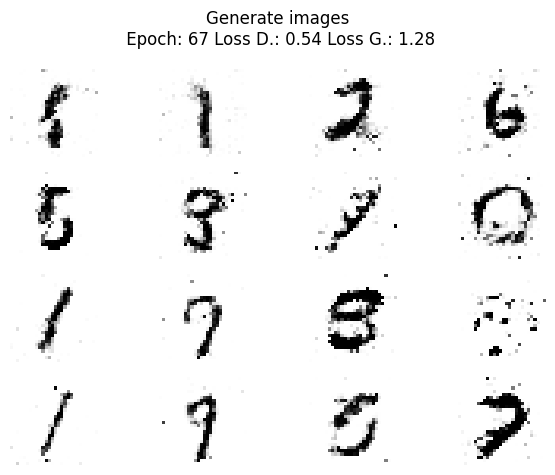

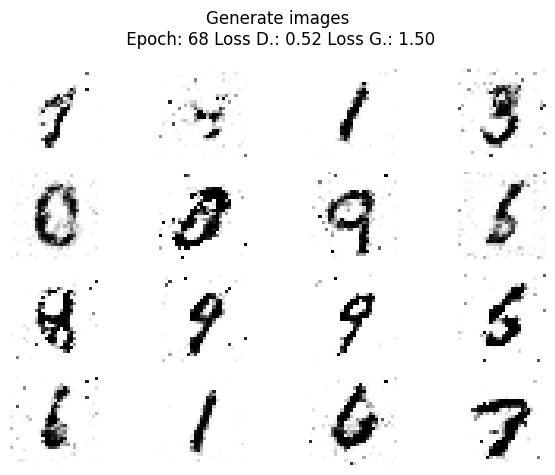

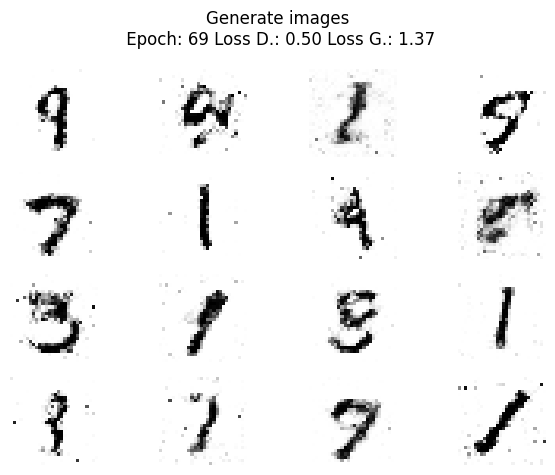

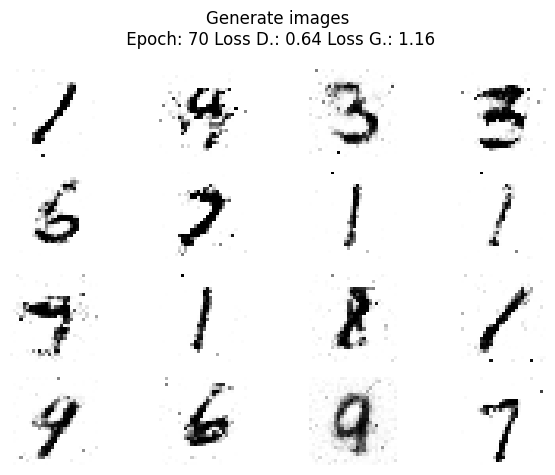

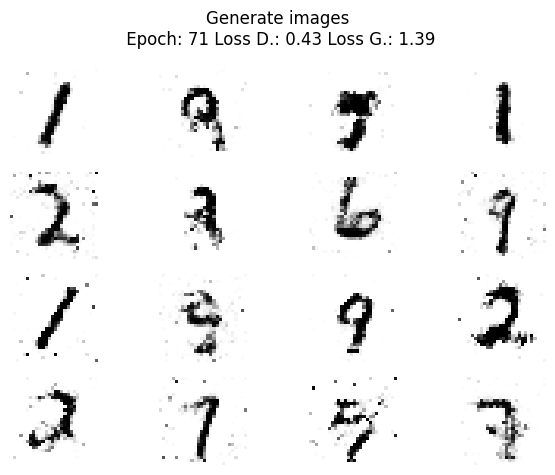

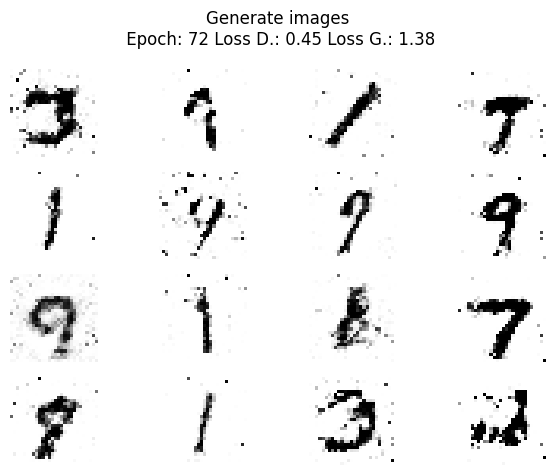

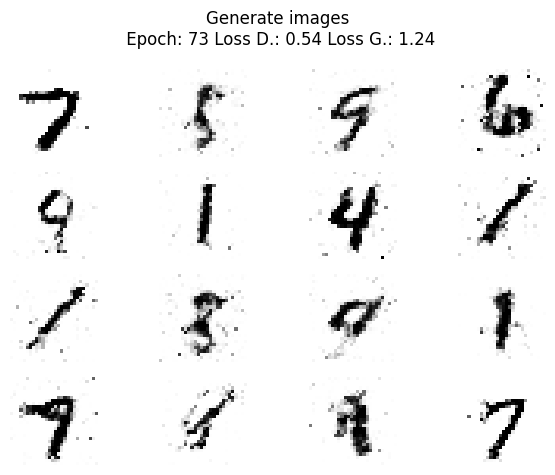

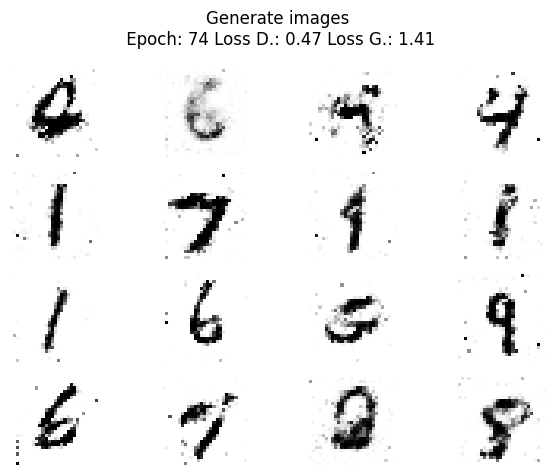

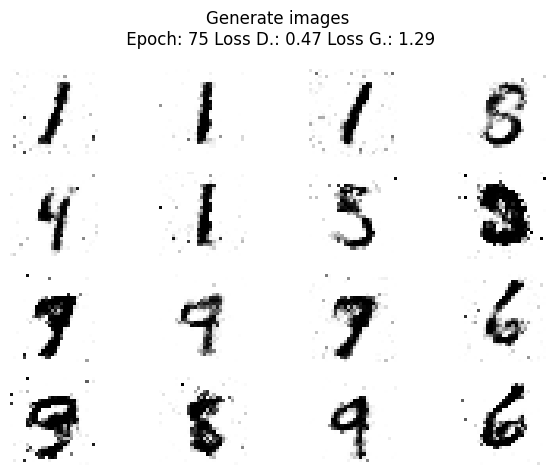

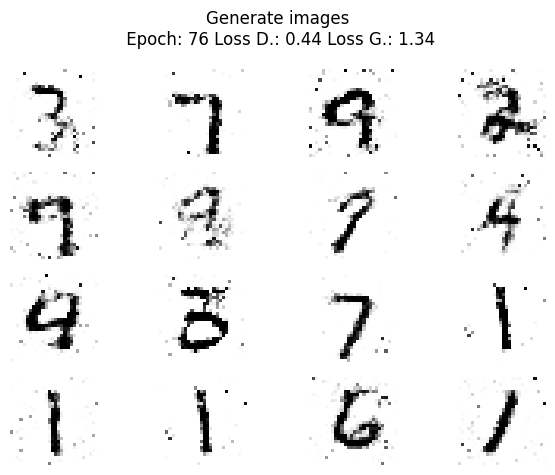

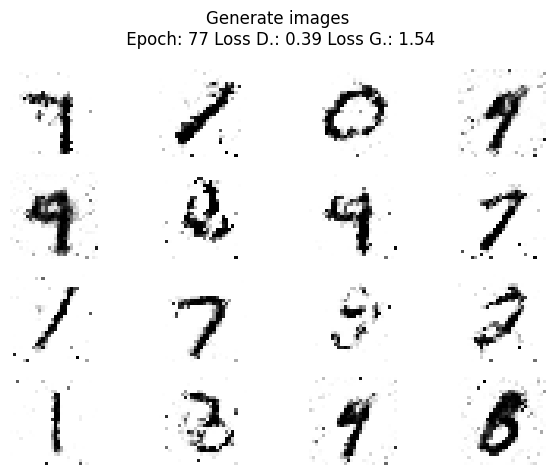

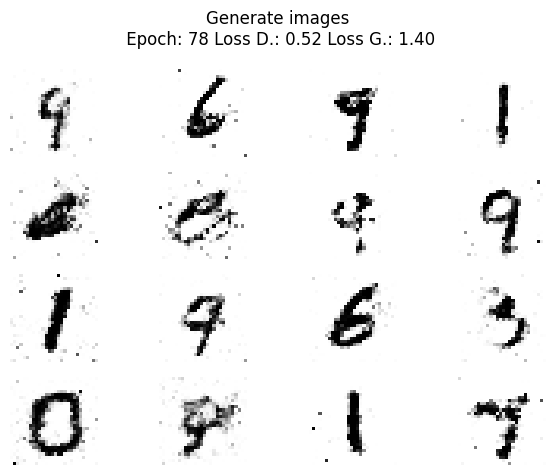

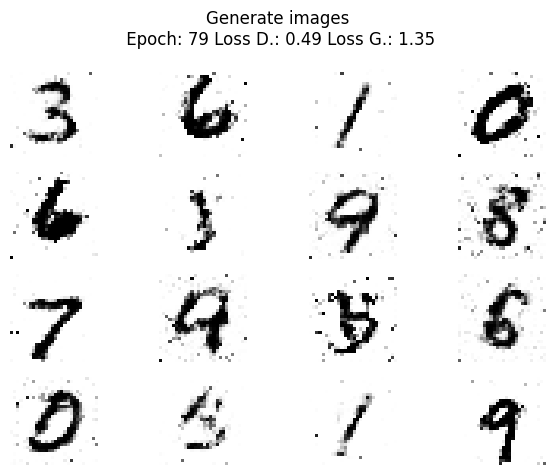

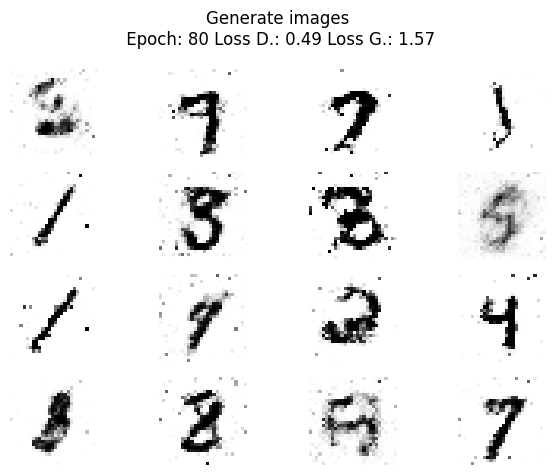

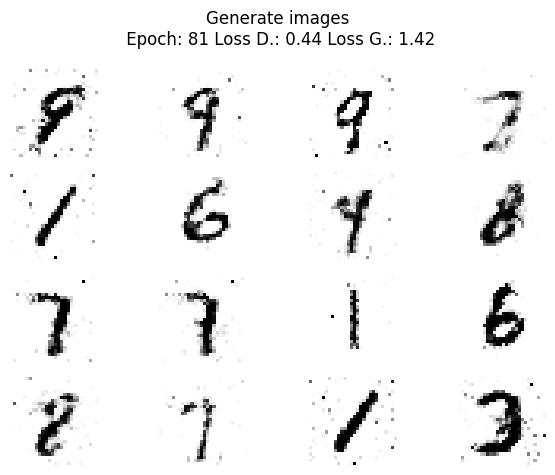

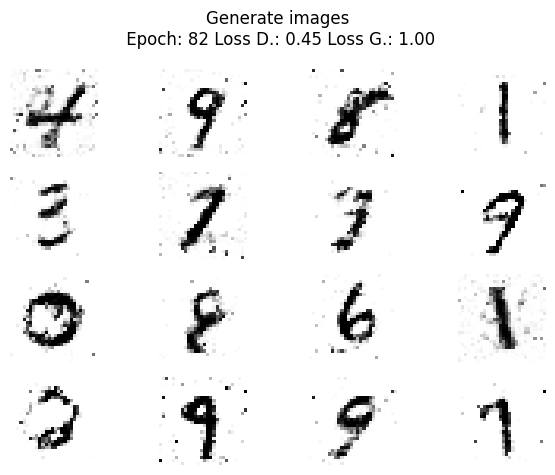

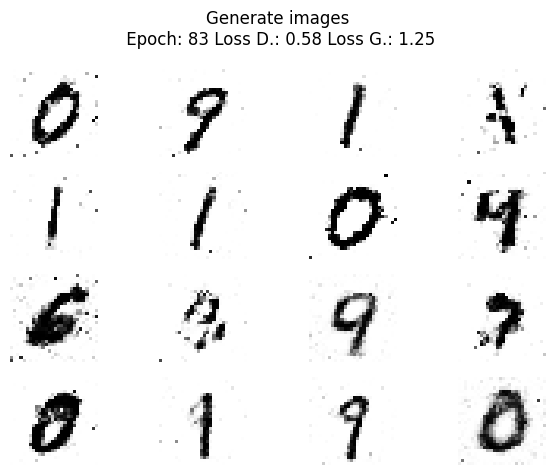

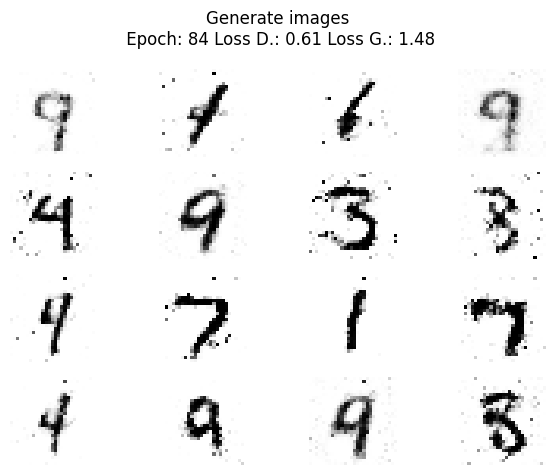

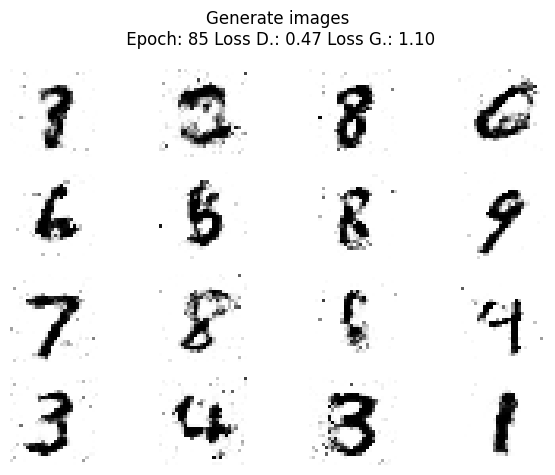

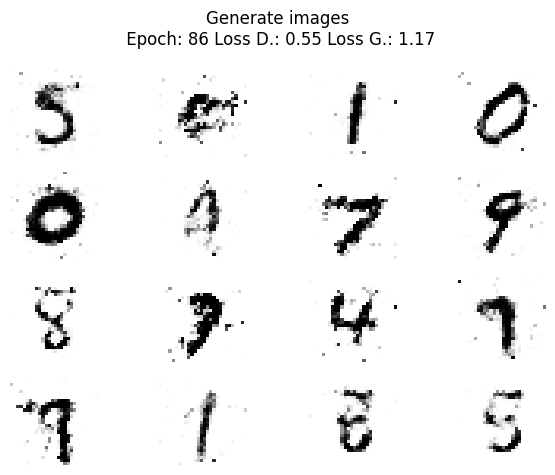

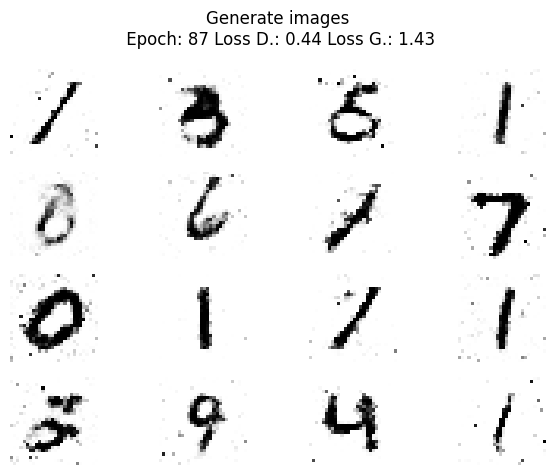

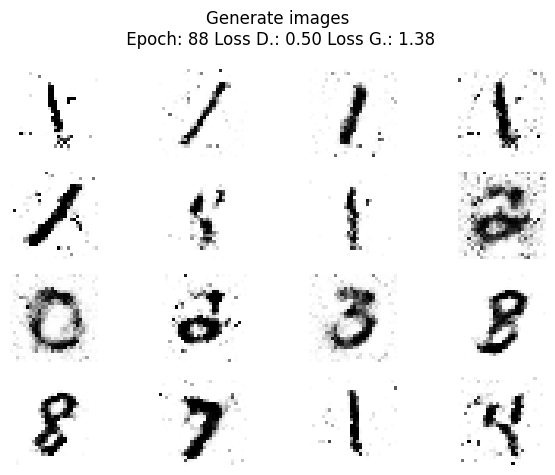

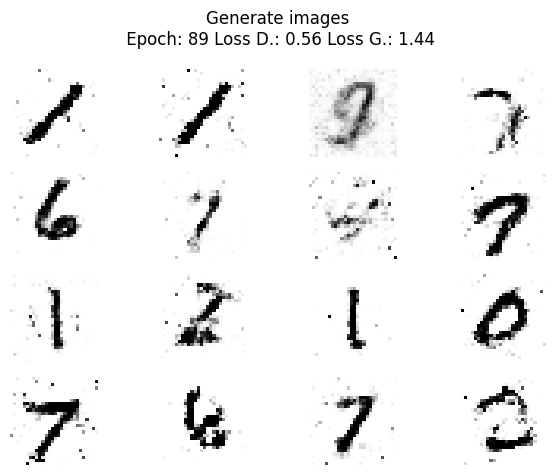

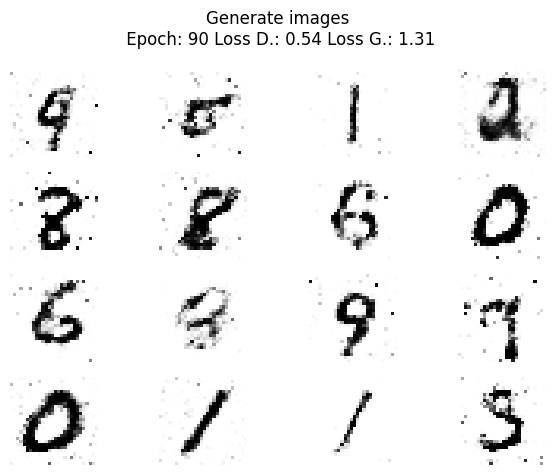

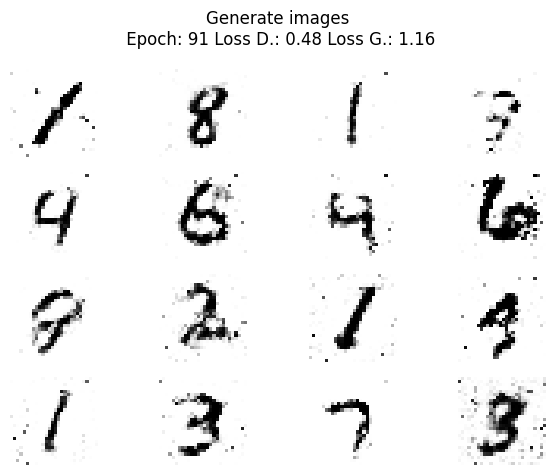

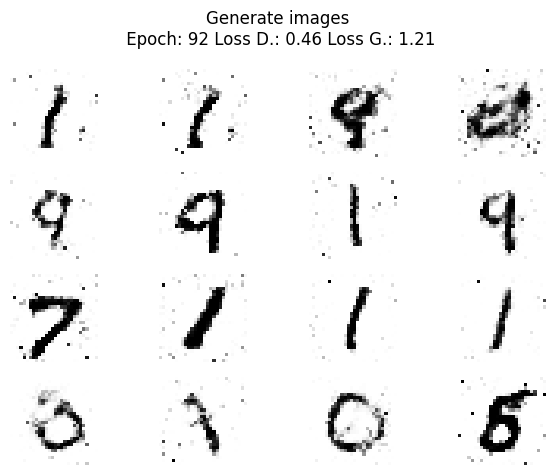

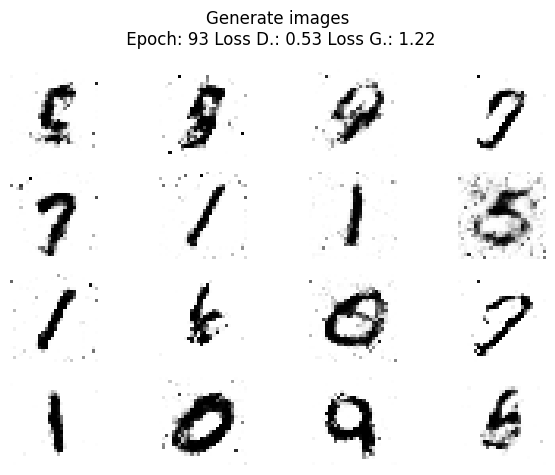

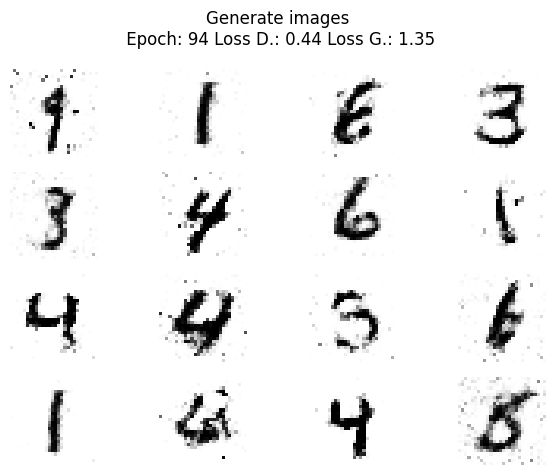

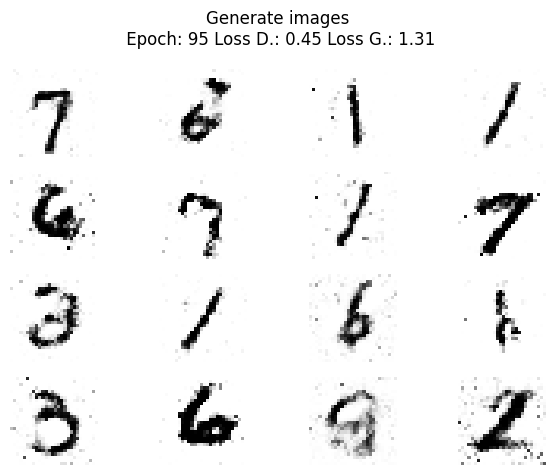

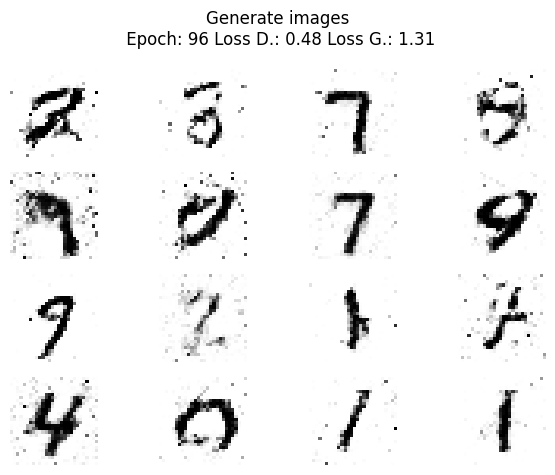

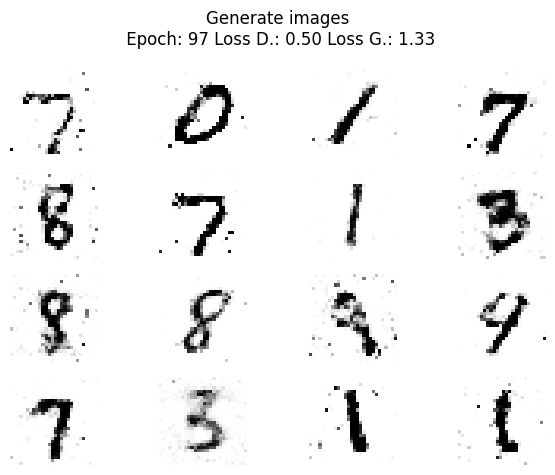

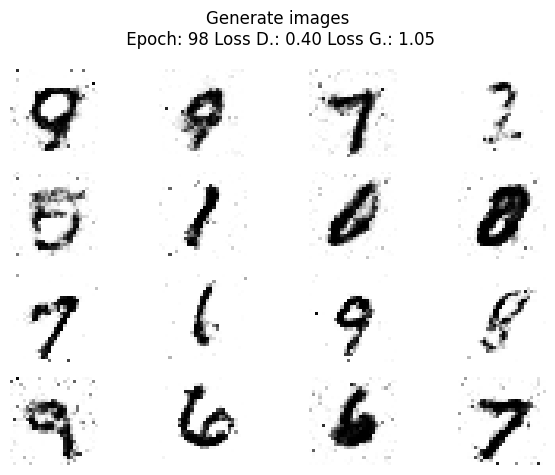

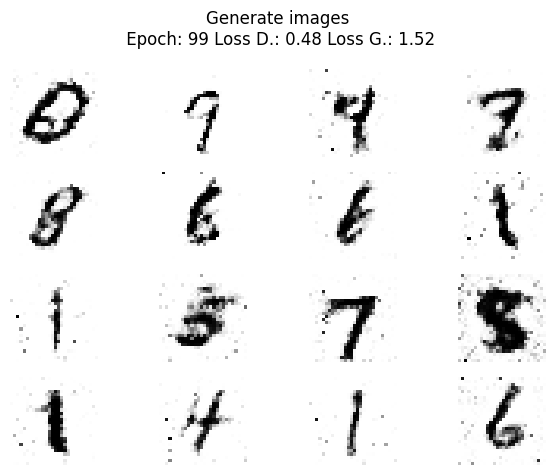

In [12]:
train_gan(batch_size=64, num_epochs=100)
